# Transfer Learning Model Comparison

Compare AlexNet, VGG16, ResNet50 and EfficientNetB0 using the result CSV files generated by notebooks 01-04.

In [1]:
%pip install -q pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


,Model,Test Accuracy,Test Loss,Training Time (min),Total Parameters,Trainable Parameters
0,AlexNet,0.8374,0.485765,6.638826,57044810,54575114
1,VGG16,0.8556,0.527991,27.851946,134301514,119586826
2,ResNet50,0.8252,0.520900,13.475431,23528522,20490
3,EfficientNetB0,0.7984,0.593477,7.818436,4020358,12810


,Model,Test Accuracy,Test Loss,Training Time (min),Total Parameters,Trainable Parameters,Test Accuracy (%),Total Parameters (M),Trainable Parameters (M)
0,AlexNet,0.84,0.49,6.64,57044810,54575114,83.74,57.04,54.58
1,VGG16,0.86,0.53,27.85,134301514,119586826,85.56,134.30,119.59
2,ResNet50,0.83,0.52,13.48,23528522,20490,82.52,23.53,0.02
3,EfficientNetB0,0.80,0.59,7.82,4020358,12810,79.84,4.02,0.01


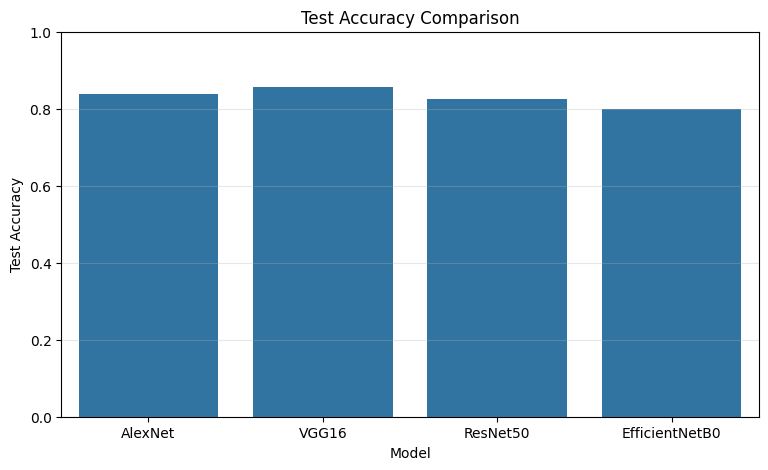

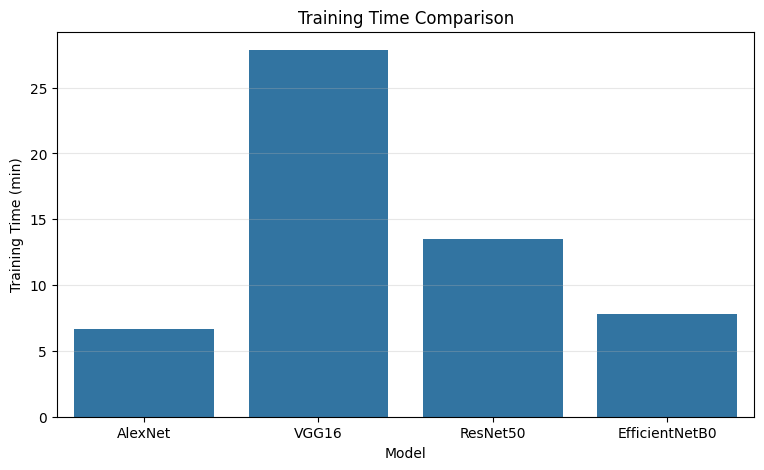

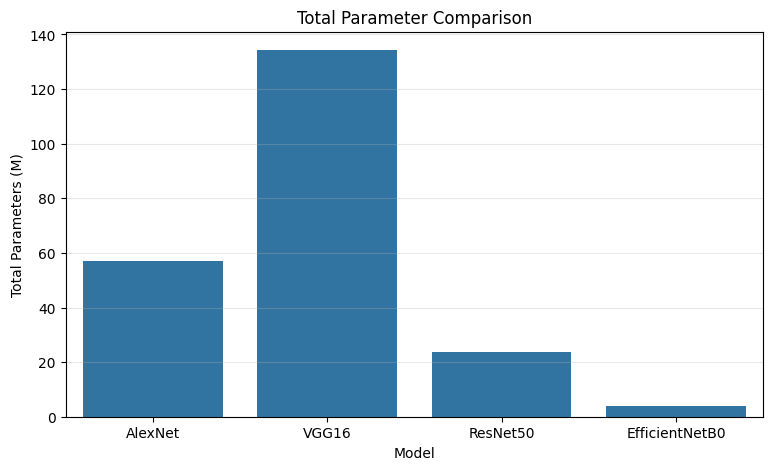

Saved: results/model_comparison.csv


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results_dir=Path("./results")
files=[results_dir/"alexnet_results.csv",results_dir/"vgg16_results.csv",results_dir/"resnet50_results.csv",results_dir/"efficientnetb0_results.csv"]

missing=[str(p) for p in files if not p.exists()]
if missing:
    print("Missing result files:")
    for p in missing: print("-",p)
    print("\nRun notebooks 01-04 first.")
else:
    comparison=pd.concat([pd.read_csv(p) for p in files],ignore_index=True)
    display(comparison)

    view=comparison.copy()
    view["Test Accuracy (%)"]=view["Test Accuracy"]*100
    view["Total Parameters (M)"]=view["Total Parameters"]/1e6
    view["Trainable Parameters (M)"]=view["Trainable Parameters"]/1e6
    display(view.round(2))

    plt.figure(figsize=(9,5))
    sns.barplot(data=comparison,x="Model",y="Test Accuracy")
    plt.ylim(0,1); plt.title("Test Accuracy Comparison"); plt.grid(axis="y",alpha=.3); plt.show()

    plt.figure(figsize=(9,5))
    sns.barplot(data=comparison,x="Model",y="Training Time (min)")
    plt.title("Training Time Comparison"); plt.grid(axis="y",alpha=.3); plt.show()

    plt.figure(figsize=(9,5))
    sns.barplot(data=view,x="Model",y="Total Parameters (M)")
    plt.title("Total Parameter Comparison"); plt.grid(axis="y",alpha=.3); plt.show()

    comparison.to_csv(results_dir/"model_comparison.csv",index=False)
    print("Saved:",results_dir/"model_comparison.csv")